# Юильский: конвейер рельефа на данных из S3

Материалы читаются прямо из бакета `geomate-project`, по каждой паре АФС + ВЛС
прогоняется полный конвейер рельефа, замеряется время каждого шага. Обработано
**100 листов из 598** — на большее нет смысла тратить трафик: разброс уже виден.

| Компонент | Расположение в бакете | Роль |
|---|---|---|
| АФС (ОФП) | `СИМА/Datasets/Юильский/ОФП/MSK86z2/` | СК, оценка материалов, фон карт |
| ВЛС | `СИМА/Datasets/Юильский/LAS/` | вход конвейера |
| Эталонная ЦМР | `СИМА/Datasets/Юильский/DSM/MSK86z2/` | восстановление абсолютных Z |

**Абсолютные Z восстанавливаются перед расчётом** (`RESTORE_Z = True`): ВЛС этого
датасета хранит ТЛО — превышение над землёй, а не отметку. Без восстановления
рельеф вырождается в плоскость, а ЦМР, уклон, экспозиция, TPI и горизонтали
выходят пустыми. Что это значит для точности — в приложении.

АФС не скачивается: GDAL читает заголовок и нужное окно по сети через `/vsis3`
(182 ГБ ОФП против 15 ГБ ВЛС). Реализация прогона — `benchmarks/s3_relief.py`.

In [1]:
import os, sys, warnings
from pathlib import Path

warnings.filterwarnings('ignore')
BACKEND = Path(os.environ.get('SIMA_BACKEND', Path.cwd())).resolve()
if not (BACKEND / 'benchmarks').is_dir():
    raise RuntimeError(f'Не найден каталог benchmarks в {BACKEND}; задайте SIMA_BACKEND')
sys.path.insert(0, str(BACKEND / 'benchmarks'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import relief_bench as RB
import s3_relief as SR
RB.quiet_gdal()   # ОФП бакета несут битые IFD пирамид: шум GDAL к расчёту не относится

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)
plt.rcParams['figure.dpi'] = 100
BLUE, TEAL, RED, GREEN, ORANGE = '#3C6E9F', '#5AA9A3', '#C0504D', '#6A9C55', '#E0873A'


def kpi_panel(items, ncols=3):
    """Плитки с ключевыми числами: значение, подпись, уточнение."""
    nrows = int(np.ceil(len(items) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(13.5, 2.3 * nrows))
    for ax, (value, label, sub) in zip(np.atleast_1d(axes).ravel(), items):
        ax.set_facecolor('#EEF2F7')
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_visible(False)
        ax.text(.5, .66, value, ha='center', va='center', fontsize=25,
                fontweight='bold', color='#23415F')
        ax.text(.5, .34, label, ha='center', va='center', fontsize=11.5, color='#33475B')
        ax.text(.5, .13, sub, ha='center', va='center', fontsize=9, color='#8794A3')
    for ax in np.atleast_1d(axes).ravel()[len(items):]:
        ax.set_visible(False)
    fig.tight_layout()
    return fig

## 1. Параметры прогона

In [2]:
DATASET   = 'yuilskiy'   # описание бакета и правила сопоставления — в s3_relief.DATASETS
LIMIT     = 100          # пар обработать; None — все 598
OFFSET    = 0            # с какой пары начать (по алфавиту)
RESOLUTION = 1.0         # разрешение ЦМР, м
FILL_METHOD = 'laplace'  # чем заполнять пустоты растра: 'laplace' | 'idw'
RESTORE_Z = True         # восстановить абсолютные Z по эталонной ЦМР из бакета

PREVIEW_EVERY = 10       # сохранять карту каждого N-го тайла
GALLERY_MAX   = 10       # сколько карт показать в ноутбуке
RUN, RESUME   = True, True   # RUN=False — только анализ готового JSONL

runner = SR.Runner(DATASET, resolution=RESOLUTION, fill_method=FILL_METHOD,
                   restore_z=RESTORE_Z, preview_every=PREVIEW_EVERY)
print(f'{runner.ds.title}: результаты → {runner.results_path}')

Юильский: результаты → /Users/sergeyzay/Documents/НЕДРА/СИМА/sima-web/backend/benchmarks/results_s3_yuilskiy/results.jsonl


## 2. Каталог бакета и прогон

Пары сопоставляются по имени номенклатурного листа (суффикс `_ground_TLO`
отбрасывается). Записи пишутся в JSONL построчно: прерванный прогон продолжается
с места остановки, упавший тайл не роняет остальные.

In [3]:
cat = runner.catalog()
ids = runner.select(LIMIT, OFFSET)
print(f'АФС {len(cat.afs)}   ВЛС {len(cat.las)}   эталонов {len(cat.ref)}   '
      f'полных пар {len(cat.pairs)}')
print(f'в прогоне: {len(ids)} тайлов, {cat.size_gb(ids):.2f} ГБ ВЛС\n')

records = runner.run(ids, resume=RESUME) if RUN else runner.load_results(
    {cat.names[i] for i in ids})
ok  = [r for r in records if r['status'] == 'done']
bad = [r for r in records if r['status'] != 'done']
df = SR.frame(records)
print(f'\nуспешно {len(ok)}, с ошибкой {len(bad)}')
for r in bad:
    print(f"  ✗ {r['name']}: {r['reason']}")

АФС 1235   ВЛС 598   эталонов 1235   полных пар 598
в прогоне: 100 тайлов, 2.06 ГБ ВЛС

к обработке: 0 из 100 (уже в JSONL: 100)



успешно 100, с ошибкой 0


## 3. Главное

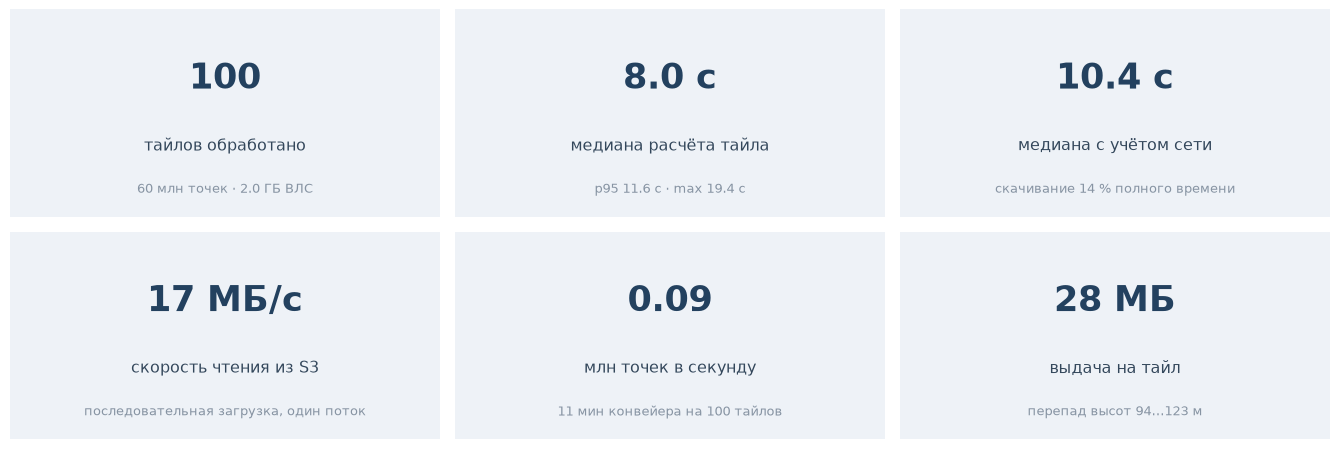

In [4]:
p, tot = df['pipeline_s'], df['total_s']
kpi_panel([
    (f'{len(df)}', 'тайлов обработано',
     f"{df['points'].sum()/1e6:.0f} млн точек · {df['las_MB'].sum()/1024:.1f} ГБ ВЛС"),
    (f'{p.median():.1f} с', 'медиана расчёта тайла',
     f"p95 {p.quantile(.95):.1f} с · max {p.max():.1f} с"),
    (f'{tot.median():.1f} с', 'медиана с учётом сети',
     f"скачивание {100*df['download_s'].sum()/tot.sum():.0f} % полного времени"),
    (f"{df['las_MB'].sum()/df['download_s'].sum():.0f} МБ/с", 'скорость чтения из S3',
     'последовательная загрузка, один поток'),
    (f"{df['points'].sum()/p.sum()/1e6:.2f}", 'млн точек в секунду',
     f"{p.sum()/60:.0f} мин конвейера на {len(df)} тайлов"),
    (f"{SR.artifacts_frame(records)['сумма_MB'].sum()/len(df):.0f} МБ", 'выдача на тайл',
     f"перепад высот {df['dtm_z_min'].min():.0f}…{df['dtm_z_max'].max():.0f} м"),
])
plt.show()

## 4. Карты результата

Каждый десятый тайл: фрагмент АФС и рядом всё, что построил сервис, — ЦМР,
сглаженная ЦМР, ЦММ, высота объектов над землёй, уклон, экспозиция, TPI. Карты
сохраняются прогоном на диск и подтягиваются сюда, поэтому остаются на месте при
повторном открытии ноутбука.

Осмысленность всех слоёв — прямое следствие восстановления абсолютных Z: на
исходном ТЛО содержательной была бы только ЦММ.

P-42-042-225-d


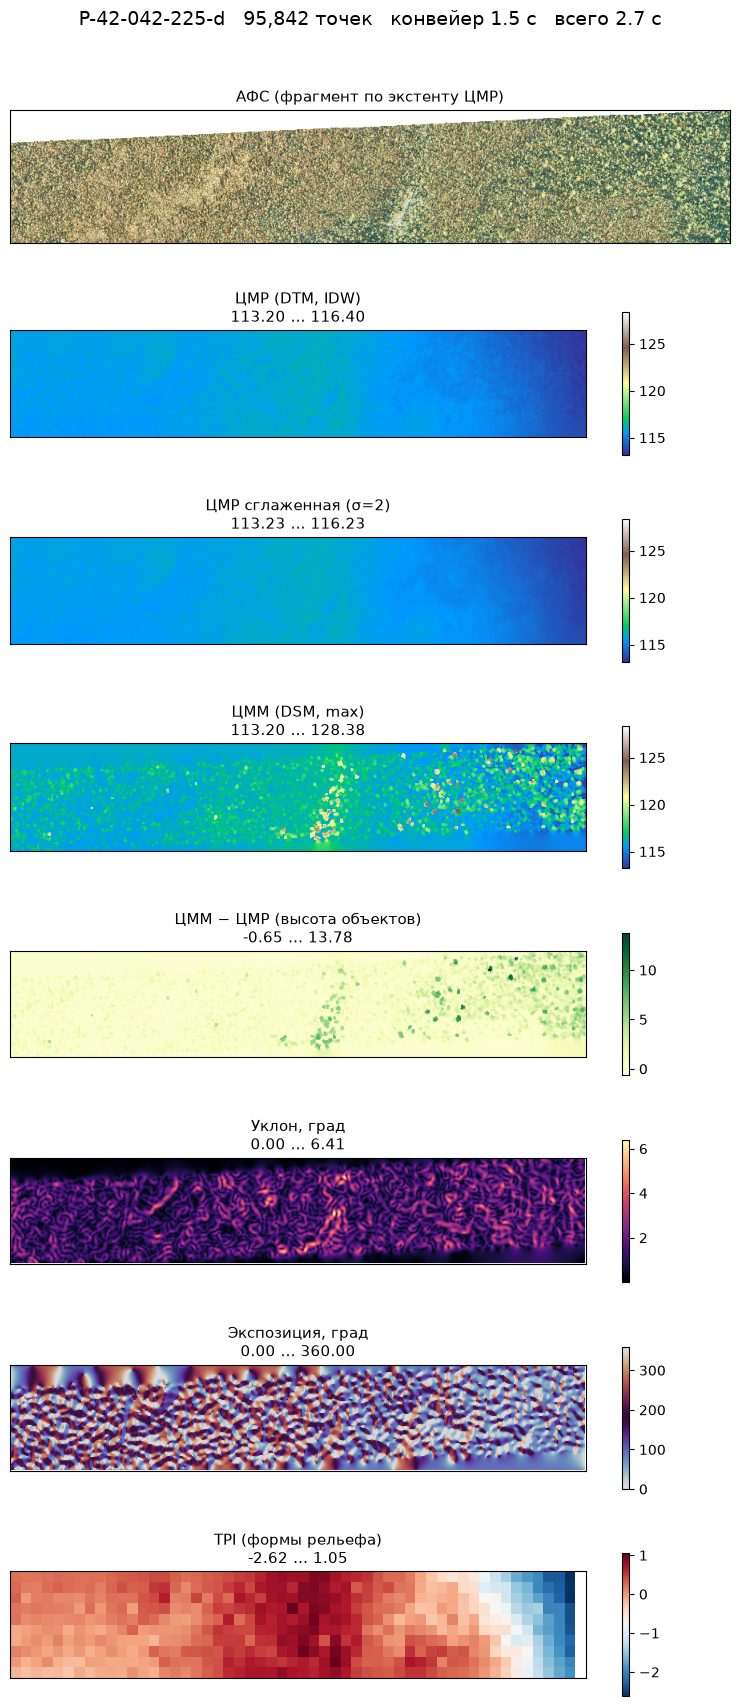

P-42-042-228-d


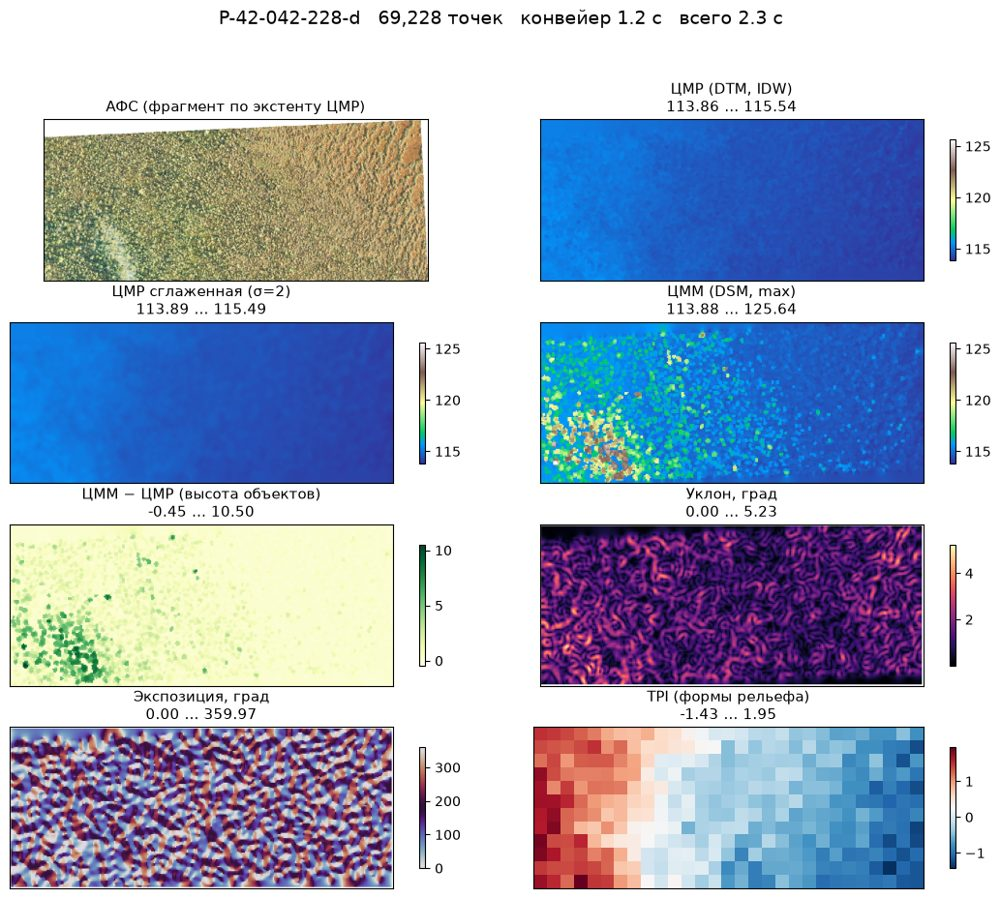

P-42-042-246-b


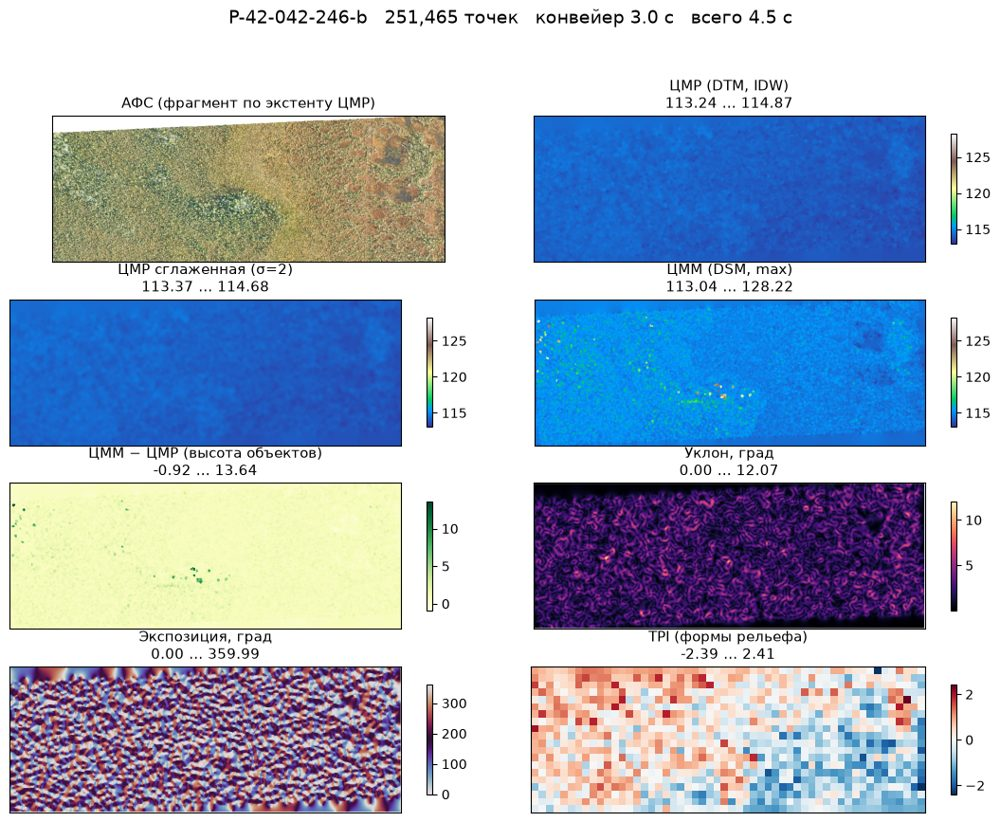

P-42-042-247-h


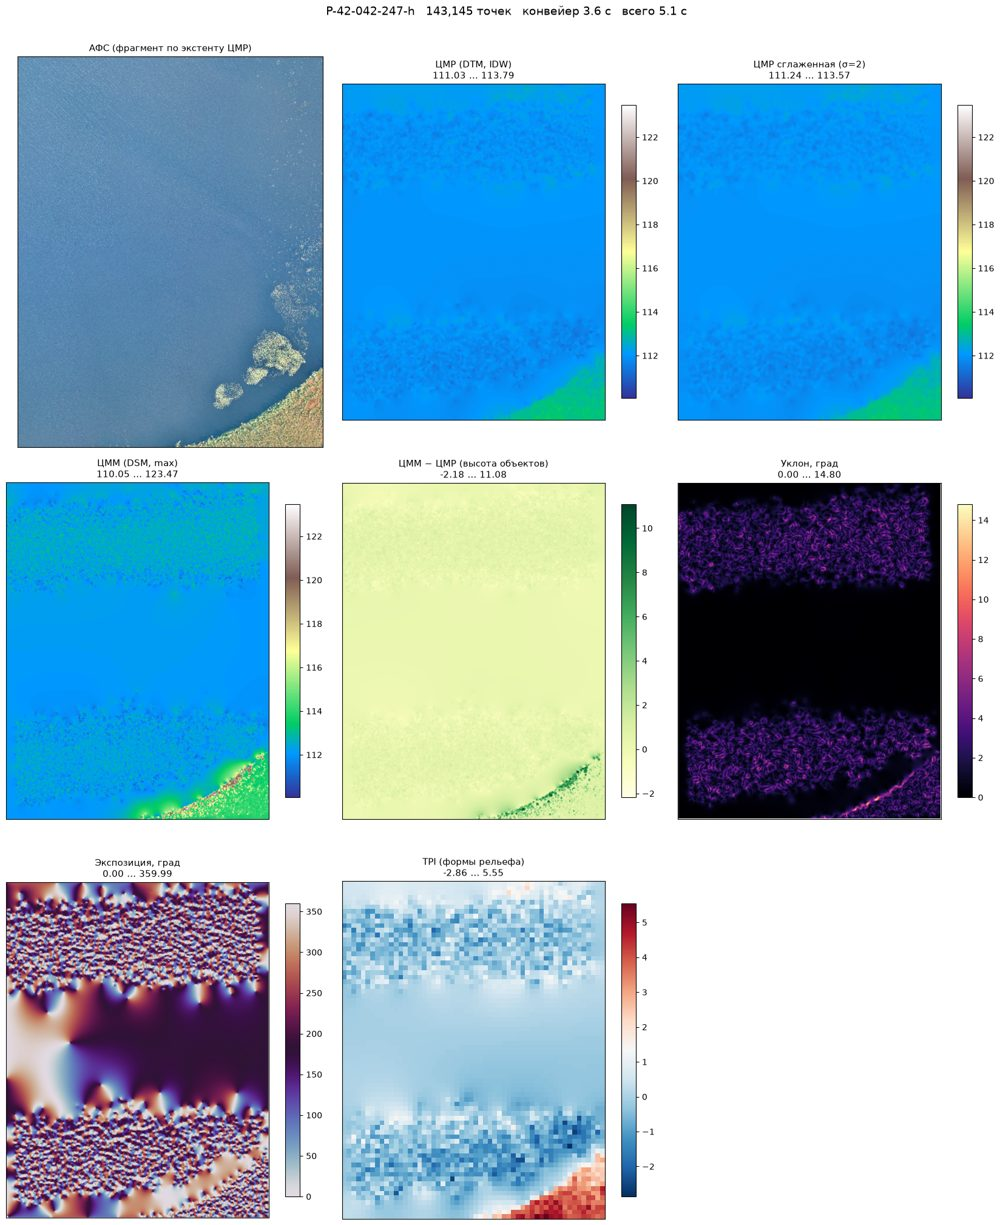

P-42-042-249-e


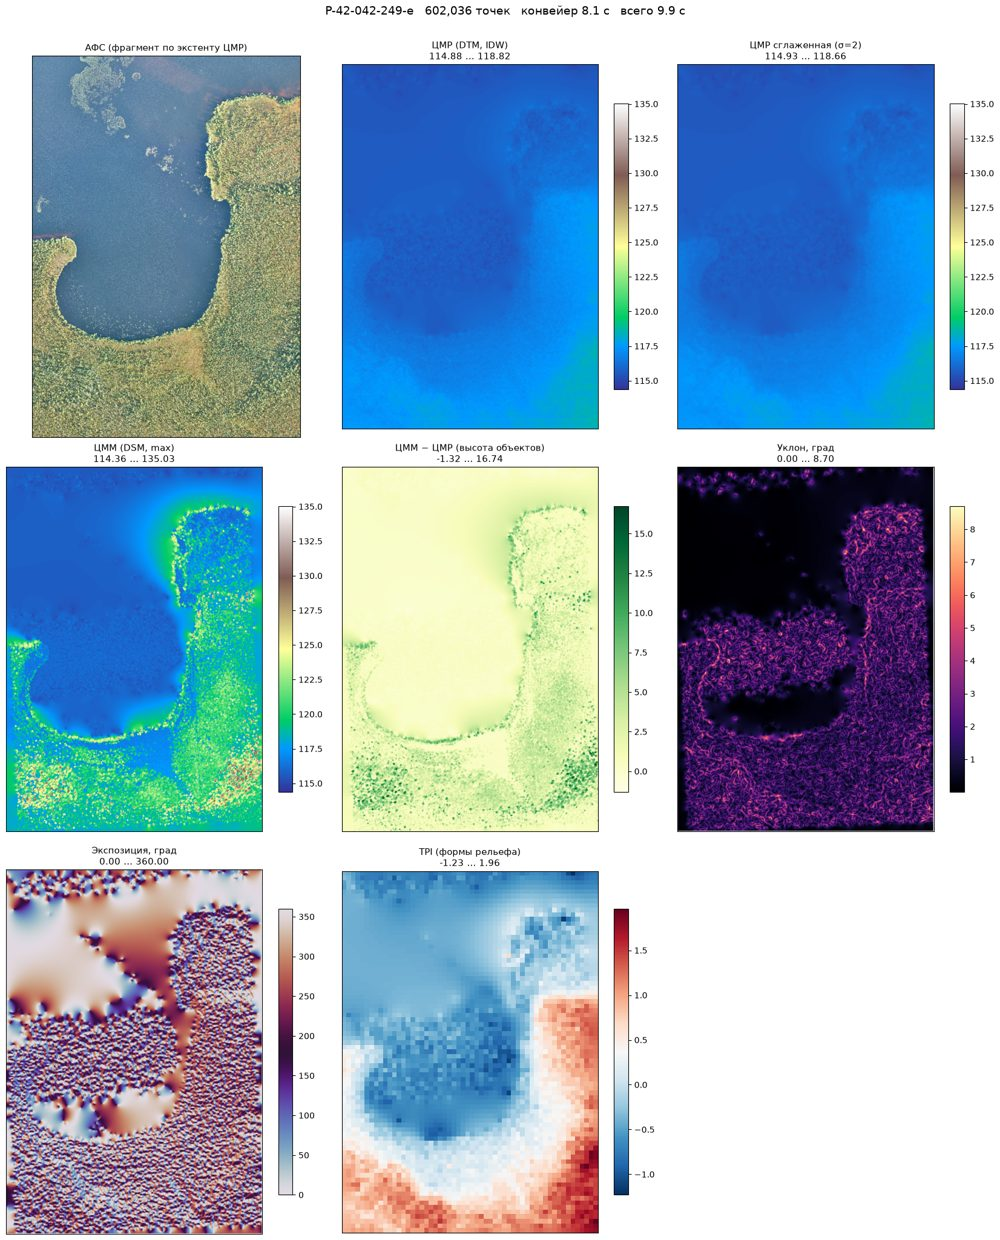

P-42-042-251-a


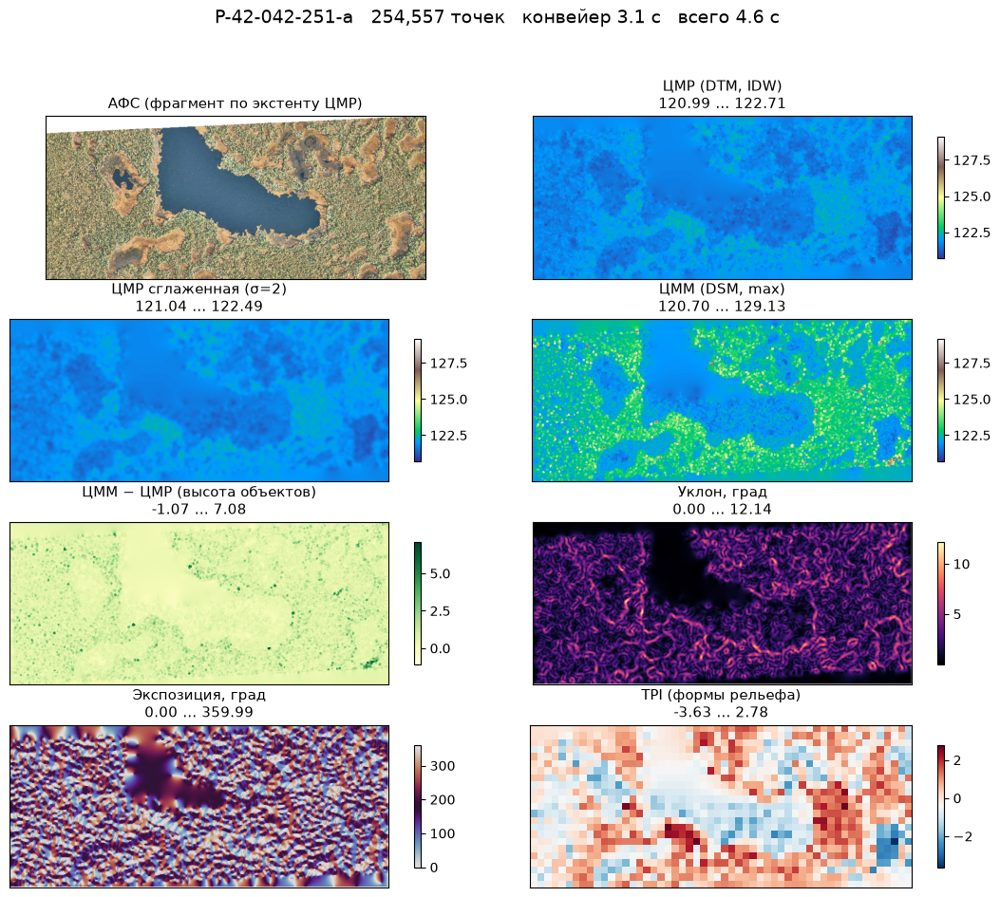

P-42-042-252-i


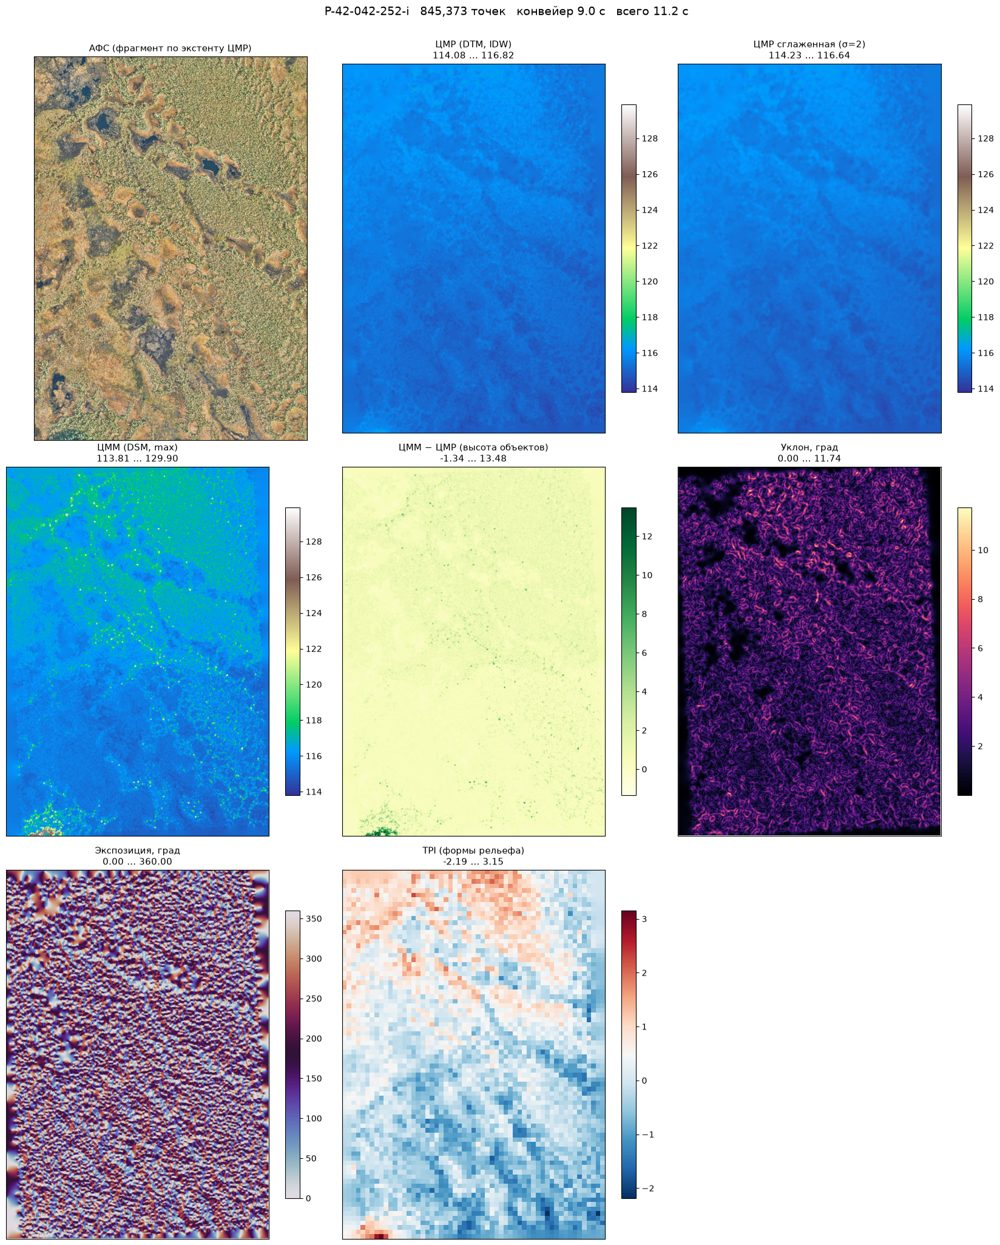

P-42-053-015-b


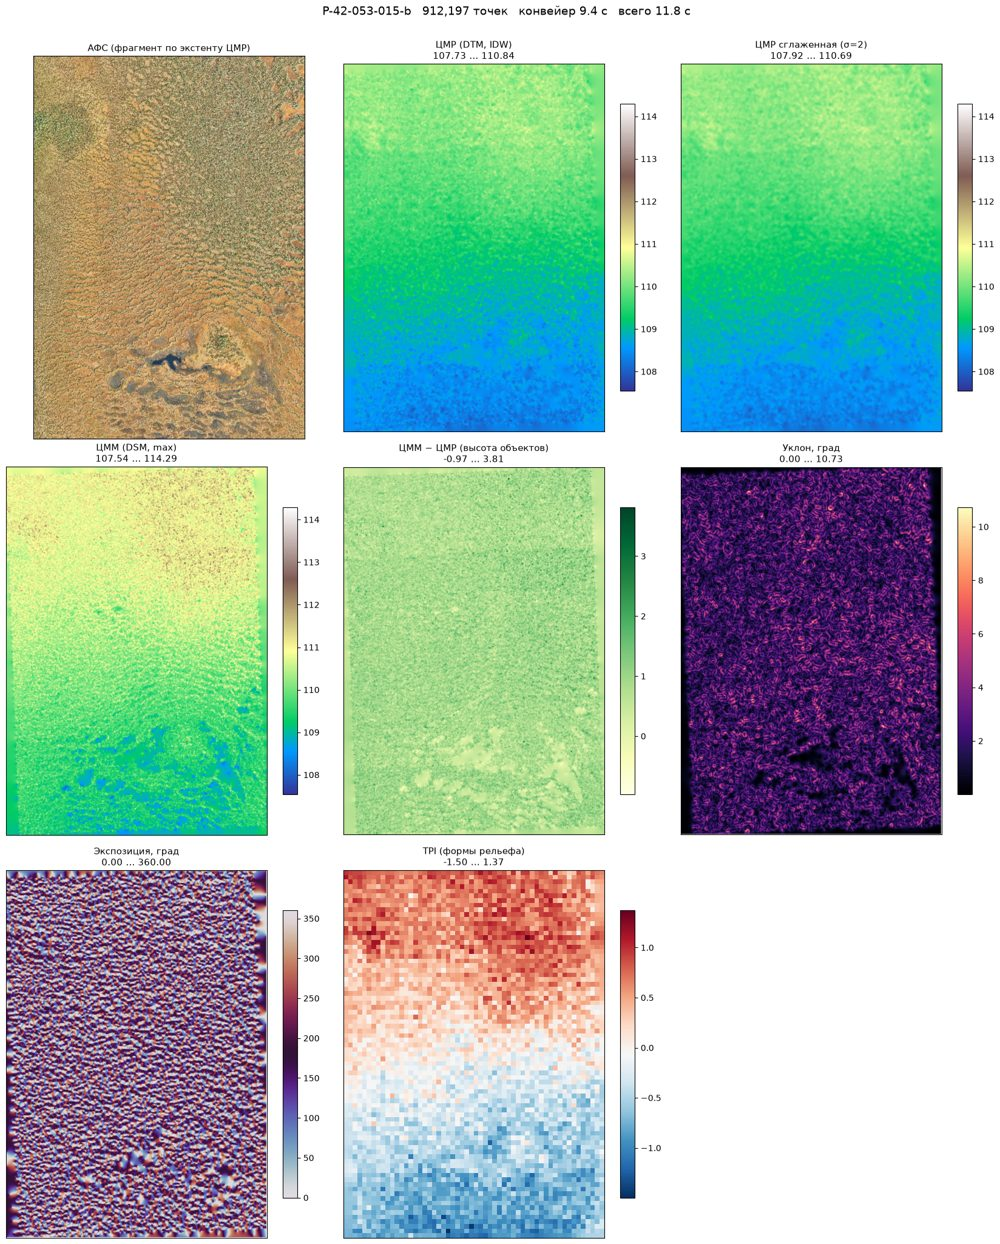

P-42-053-047-i


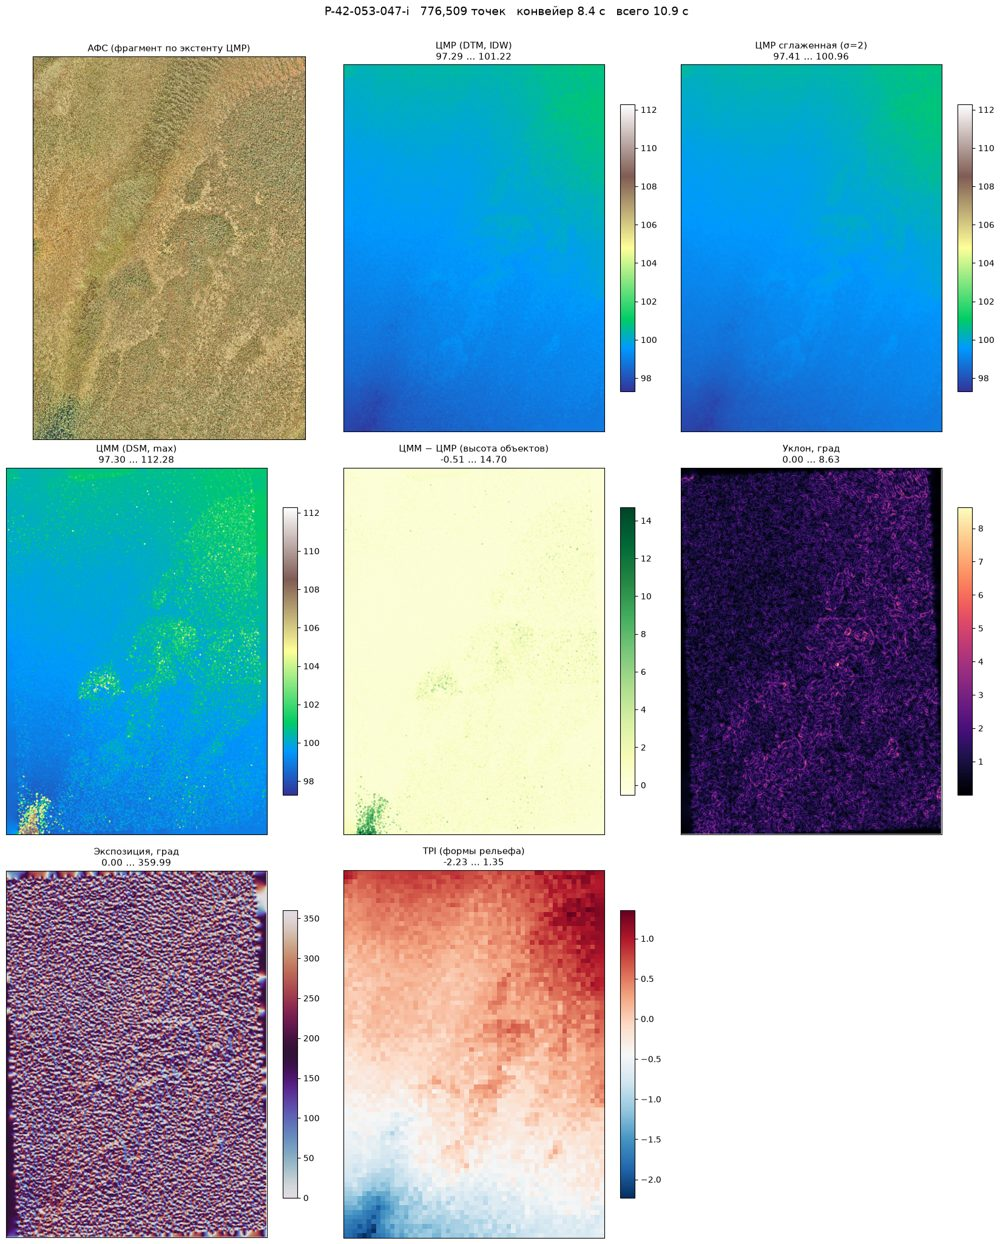

P-42-053-063-h

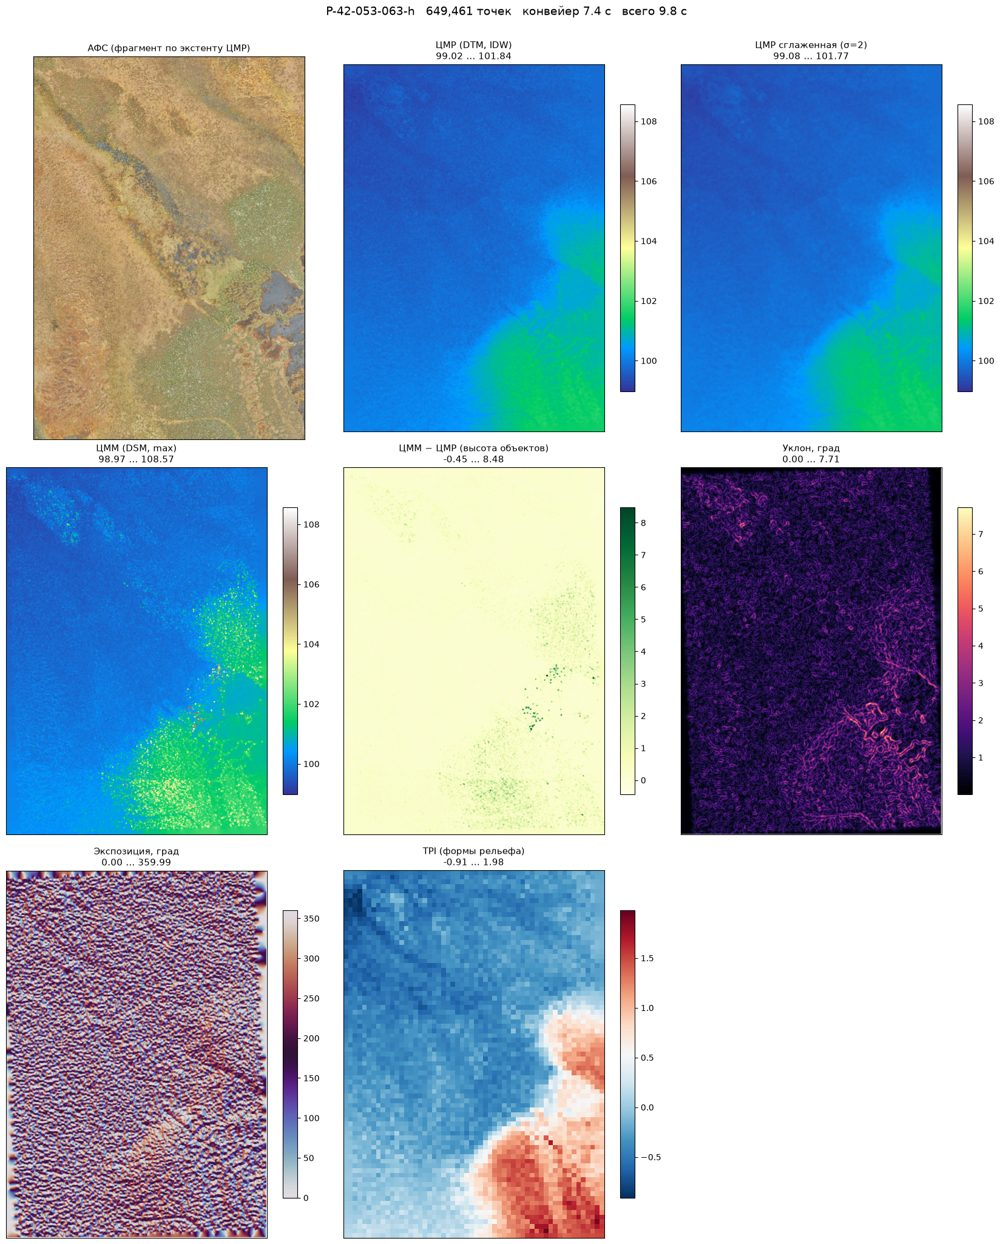

Полноразмерные превью: /Users/sergeyzay/Documents/НЕДРА/СИМА/sima-web/backend/benchmarks/results_s3_yuilskiy/previews


In [5]:
SR.gallery(runner.preview_dir, max_n=GALLERY_MAX)
print(f'Полноразмерные превью: {runner.preview_dir}')

## 5. Время: конвейер и сеть

`pipeline_s` — время расчёта по замерам сервиса, без сети. `total_s` — полное время
тайла, включая скачивание ВЛС и чтение заголовка АФС по сети.

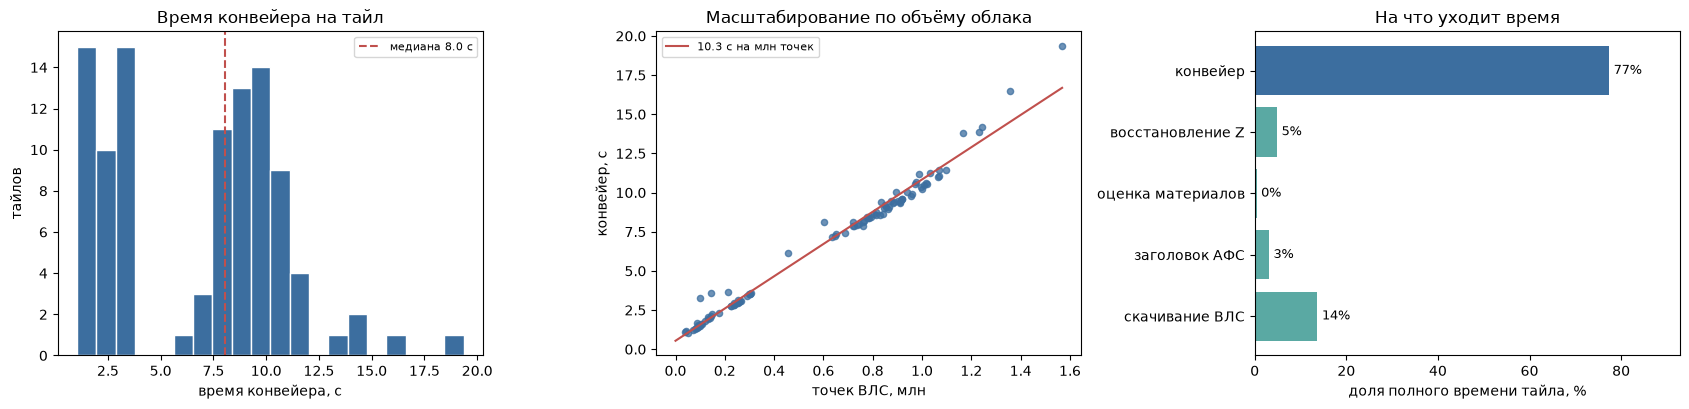

,"конвейер, с","всего с сетью, с"
min,1.0,2.0
медиана,8.0,10.4
среднее,6.8,8.7
p95,11.6,14.2
max,19.4,23.1
СУММА,676.6,874.5


In [6]:
p, tot = df['pipeline_s'], df['total_s']
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))

axes[0].hist(p, bins=20, color=BLUE, edgecolor='white')
axes[0].axvline(p.median(), color=RED, ls='--', label=f'медиана {p.median():.1f} с')
axes[0].set_xlabel('время конвейера, с'); axes[0].set_ylabel('тайлов')
axes[0].set_title('Время конвейера на тайл'); axes[0].legend(fontsize=8)

x = df['points'] / 1e6
k = np.polyfit(x, p, 1)
axes[1].scatter(x, p, s=20, alpha=.75, color=BLUE)
xs = np.linspace(0, x.max(), 50)
axes[1].plot(xs, np.polyval(k, xs), color=RED, lw=1.5, label=f'{k[0]:.1f} с на млн точек')
axes[1].set_xlabel('точек ВЛС, млн'); axes[1].set_ylabel('конвейер, с')
axes[1].set_title('Масштабирование по объёму облака'); axes[1].legend(fontsize=8)

parts = pd.Series({'скачивание ВЛС': df['download_s'].sum(),
                   'заголовок АФС': df['afs_hdr_s'].sum(),
                   'оценка материалов': df['assess_s'].sum(),
                   'восстановление Z': df['restore_s'].sum(),
                   'конвейер': p.sum()})
parts = 100 * parts[parts > 0] / tot.sum()
axes[2].barh(parts.index, parts.values, color=[BLUE if i == 'конвейер' else TEAL
                                               for i in parts.index])
for i, v in enumerate(parts.values):
    axes[2].text(v + 1, i, f'{v:.0f}%', va='center', fontsize=9)
axes[2].set_xlim(0, parts.max() * 1.2)
axes[2].set_xlabel('доля полного времени тайла, %')
axes[2].set_title('На что уходит время')

fig.tight_layout(); plt.show()

pd.DataFrame({
    'конвейер, с': [p.min(), p.median(), p.mean(), p.quantile(.95), p.max(), p.sum()],
    'всего с сетью, с': [tot.min(), tot.median(), tot.mean(), tot.quantile(.95),
                         tot.max(), tot.sum()],
}, index=['min', 'медиана', 'среднее', 'p95', 'max', 'СУММА']).round(1)

## 6. Время по шагам конвейера

Из чего складывается расчёт тайла и насколько устойчив каждый шаг.

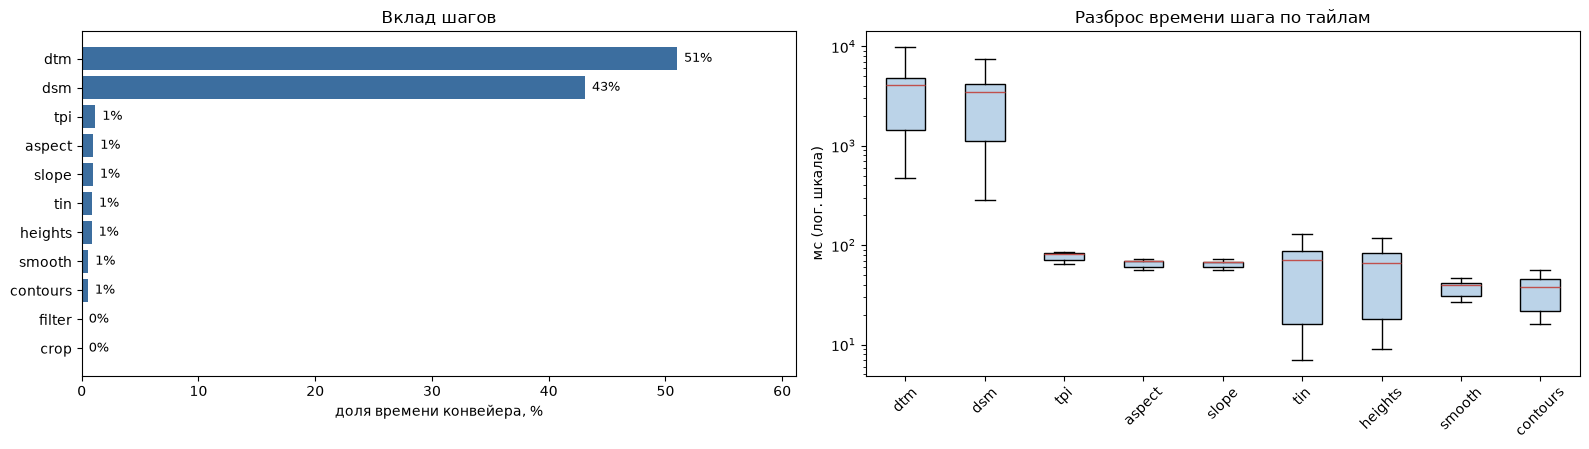

In [7]:
steps = df[[f'ms_{s}' for s in RB.STEP_ORDER]].rename(columns=lambda c: c[3:])
share = (steps.sum() / steps.sum().sum() * 100).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 4.6))
axes[0].barh(share.index, share.values, color=BLUE)
for i, v in enumerate(share.values):
    axes[0].text(v + .6, i, f'{v:.0f}%', va='center', fontsize=9)
axes[0].set_xlim(0, share.max() * 1.2)
axes[0].set_xlabel('доля времени конвейера, %'); axes[0].set_title('Вклад шагов')

order = [c for c in share.index[::-1] if steps[c].notna().any() and steps[c].sum() > 0]
axes[1].boxplot([steps[c].dropna() for c in order], tick_labels=order, showfliers=False,
                patch_artist=True, boxprops=dict(facecolor='#BBD3E8'),
                medianprops=dict(color=RED))
axes[1].set_yscale('log'); axes[1].set_ylabel('мс (лог. шкала)')
axes[1].set_title('Разброс времени шага по тайлам')
axes[1].tick_params(axis='x', rotation=45)
fig.tight_layout(); plt.show()

## 7. Что и сколько на выходе

Время привязано к породившему шагу: `dtm` и `ground_las` выходят из одного шага,
четыре шейпфайла горизонталей — тоже, поэтому время агрегируется по парам
(тайл, шаг), а размеры — по файлам.

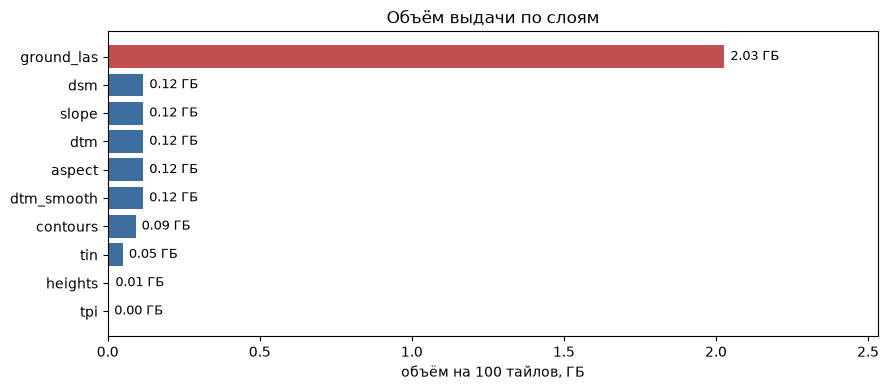

,формат,файлов,медиана_KB,сумма_MB,медиана_мс,сумма_с
layer,,,,,,
ground_las,las,100,26066.58,2076.09,4056.0,343.24
dsm,geotiff,100,1747.54,119.79,3486.5,290.17
aspect,geotiff,100,1742.24,119.24,69.0,6.62
dtm,geotiff,100,1742.24,119.24,4056.0,343.24
slope,geotiff,100,1742.24,119.24,67.0,6.45
dtm_smooth,geotiff,100,1740.01,119.07,40.0,3.73
contours,shp,400,91.62,93.67,38.0,3.54
tin,dxf,100,742.05,50.74,71.5,5.91
heights,shp,100,75.93,5.22,65.5,5.71


In [8]:
by_layer = SR.artifacts_frame(records)
fig, ax = plt.subplots(figsize=(9, 4))
sh = by_layer['сумма_MB'].sort_values()
ax.barh(sh.index, sh.values / 1024,
        color=[RED if i == 'ground_las' else BLUE for i in sh.index])
for i, v in enumerate(sh.values / 1024):
    ax.text(v + .02, i, f'{v:.2f} ГБ', va='center', fontsize=9)
ax.set_xlim(0, (sh.values / 1024).max() * 1.25)
ax.set_xlabel(f'объём на {len(df)} тайлов, ГБ'); ax.set_title('Объём выдачи по слоям')
fig.tight_layout(); plt.show()

by_layer[['формат', 'файлов', 'медиана_KB', 'сумма_MB', 'медиана_мс', 'сумма_с']]

## 8. Итог

In [9]:
steps = df[[f'ms_{s}' for s in RB.STEP_ORDER]].rename(columns=lambda c: c[3:])
top = (100 * steps.sum() / steps.sum().sum()).sort_values(ascending=False)
print('\n'.join([
    f'Датасет:            {runner.ds.title}, {len(cat.pairs)} пар АФС+ВЛС в бакете {SR.BUCKET}',
    f'Обработано:         {len(df)} тайлов (ошибок {len(bad)}), '
    f'{df["points"].sum()/1e6:.1f} млн точек, {df["las_MB"].sum()/1024:.2f} ГБ ВЛС',
    f'Режим Z:            восстановлены из ТЛО по эталонной ЦМР бакета '
    f'(+{df["restore_s"].median()*1000:.0f} мс на тайл)',
    f'Время расчёта:      медиана {df["pipeline_s"].median():.1f} с, '
    f'p95 {df["pipeline_s"].quantile(.95):.1f} с, сумма {df["pipeline_s"].sum()/60:.1f} мин',
    f'Время с сетью:      медиана {df["total_s"].median():.1f} с, '
    f'сумма {df["total_s"].sum()/60:.1f} мин (скачивание '
    f'{100*df["download_s"].sum()/df["total_s"].sum():.0f} %)',
    f'Пропускная спос.:   {df["points"].sum()/df["pipeline_s"].sum()/1e6:.2f} млн точек/с '
    f'на конвейере, один поток',
    f'Самые дорогие шаги: {top.index[0]} {top.iloc[0]:.0f} %, {top.index[1]} {top.iloc[1]:.0f} %',
    f'Заполнение пустот:  {FILL_METHOD} на всех пустотах, полнота растра '
    f'{df["dtm_valid_%"].median():.0f} %',
    f'Все 598 пар:        оценка {598*df["total_s"].median()/3600:.1f} ч и '
    f'{598*df["las_MB"].median()/1024:.0f} ГБ загрузки в один поток',
]))

Датасет:            Юильский, 598 пар АФС+ВЛС в бакете geomate-project
Обработано:         100 тайлов (ошибок 0), 60.5 млн точек, 2.01 ГБ ВЛС
Режим Z:            восстановлены из ТЛО по эталонной ЦМР бакета (+393 мс на тайл)
Время расчёта:      медиана 8.0 с, p95 11.6 с, сумма 11.3 мин
Время с сетью:      медиана 10.4 с, сумма 14.6 мин (скачивание 14 %)
Пропускная спос.:   0.09 млн точек/с на конвейере, один поток
Самые дорогие шаги: dtm 51 %, dsm 43 %
Заполнение пустот:  laplace на всех пустотах, полнота растра 100 %
Все 598 пар:        оценка 1.7 ч и 15 ГБ загрузки в один поток


---
## Приложение

**Что означает восстановление Z.** ВЛС датасета хранит ТЛО: `Z ∈ [−0.7; 20.0]` м
при классах 1–5 — это превышение над землёй. Абсолютные отметки восстанавливаются
по эталонной ЦМР из того же бакета (`relief_bench.restore_absolute`): ground-точки
получают Z эталона, остальные — Z эталона плюс своё превышение. Замеры времени это
не искажает (восстановление идёт вне сервиса и учтено отдельной строкой), но
точность такой ЦМР измеряла бы не съёмку, а реконструкцию поверхности сервисом —
поэтому здесь она и не измеряется. Независимая оценка точности — в
`relief_benchmark.ipynb`, на датасете с эталоном на каждый лист.

**СК.** В заголовках ВЛС система координат не объявлена, поэтому шаг `crs_check`
сверку пропускает и расчёт не блокирует; СК берётся из АФС — MSK86z2, Transverse
Mercator на СК-42, осевой меридиан 66.05°.

**Ключи доступа** не зашиты в ноутбук: `S3_ACCESS_KEY` / `S3_SECRET_KEY` в
окружении либо `backend/.s3_credentials.json` (файл в `.gitignore`).

**Параметры расчёта** — общие с `relief_demo.ipynb` и `relief_benchmark.ipynb`,
чтобы замеры были сопоставимы между прогонами.

In [10]:
import inspect
print(inspect.getsource(RB.default_params))

def default_params(crs_wkt: str, resolution: float = 1.0,
                   fill_method: str = DEFAULT_FILL_METHOD) -> ReliefParams:
    """Параметры Q3, выровненные с легаси-прототипом и relief_demo.ipynb.

    Args:
        fill_method: чем заполнять пустоты — "laplace" или "idw".
    """
    if fill_method not in ("laplace", "idw"):
        raise ValueError(f"fill_method: ожидается 'laplace' или 'idw', получено {fill_method!r}")
    return ReliefParams(
        target_crs=crs_wkt,
        filter_method="smrf",
        smrf=SmrfParams(slope=0.2, window=16, threshold=0.45, scalar=1.2),
        smoothing=SmoothingParams(enabled=True, sigma=2.0, order=0, window=5),
        dsm=DsmParams(enabled=True, output_type="max", interpolate=True, fill_holes=True,
                      max_search_distance=FILL_SEARCH_PX,
                      edge_extrapolation_m=FILL_ALL_VOIDS_M,
                      fill_method=fill_method, hydro_flatten=False),
        derivatives=DerivativesParams(
         